# Customer Intelligence System — Country Development Segmentation
## Celebal Technologies Internship | Week 3 Assignment | Data Science Track

### Objective
Build an end-to-end **Customer Intelligence System** using:
- **Clustering** (K-Means, DBSCAN, Hierarchical, K-Medoids) — to discover natural country groupings
- **Classification** (LR, KNN, SVM, Decision Tree) — to predict development tier for new countries
- **Ensemble Learning** (Random Forest, AdaBoost, GBM, XGBoost, LightGBM, Stacking, Voting) — to maximize predictive accuracy

### Pipeline Design
```
Raw Country Data
     ↓
EDA + Preprocessing + Scaling
     ↓
Clustering (K-Means best k → Development Tiers)
     ↓
Label Assignment → Classification Target
     ↓
Classification + Ensemble Models
     ↓
Evaluation + Feature Importance + Insights
```

### Dataset contains

**167 countries** | **9 socioeconomic features** | No missing values


##  1. Install Required Libraries

In [42]:
# Install all required libraries
# sklearn-extra provides K-Medoids which is not in base scikit-learn
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm scikit-learn-extra scipy
!pip install "numpy<2"

##  2. Import Libraries

In [43]:

import io
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Preprocessing & Evaluation
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                              silhouette_score, accuracy_score, f1_score)
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Ensemble Methods
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, VotingClassifier,
                               StackingClassifier)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" All libraries imported successfully!")

 All libraries imported successfully!


##  3. Load Dataset
Upload `Country-data.csv` when prompted (from the Kaggle archive).  
**Alternatively**, if running locally, place the CSV in the same folder and use `pd.read_csv('Country-data.csv')`.


In [2]:
import pandas as pd

# Paste the exact copied path here directly
# This removes all Google-specific Python dependencies from your execution code
file_path = '/content/drive/MyDrive/Dataset/Country-data.csv'

df_raw = pd.read_csv(file_path)

print(f"Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
df_raw.head(10)

ModuleNotFoundError: No module named 'pandas'

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  4. Exploratory Data Analysis (EDA)

In [46]:
print("=" * 55)
print(f"Shape         : {df_raw.shape}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"Missing values:\n{df_raw.isnull().sum().to_string()}")
print("=" * 55)

# Statistical Summary
print("\n📊 Statistical Summary:")
df_raw.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])

Shape         : (167, 10)
Duplicate rows: 0
Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0

📊 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


In [47]:
# Feature Descriptions
feature_desc = {
    'child_mort' : 'Deaths of children < 5 yrs per 1000 live births',
    'exports'    : 'Exports of goods/services (% of GDP per capita)',
    'health'     : 'Total health spending (% of GDP per capita)',
    'imports'    : 'Imports of goods/services (% of GDP per capita)',
    'income'     : 'Net income per person (USD)',
    'inflation'  : 'Annual GDP growth rate (%)',
    'life_expec' : 'Average life expectancy at birth (years)',
    'total_fer'  : 'Average children per woman',
    'gdpp'       : 'GDP per capita (USD)'
}
pd.DataFrame.from_dict(feature_desc, orient='index', columns=['Description'])

,Description
child_mort,Deaths of children < 5 yrs per 1000 live births
exports,Exports of goods/services (% of GDP per capita)
health,Total health spending (% of GDP per capita)
imports,Imports of goods/services (% of GDP per capita)
income,Net income per person (USD)
inflation,Annual GDP growth rate (%)
life_expec,Average life expectancy at birth (years)
total_fer,Average children per woman
gdpp,GDP per capita (USD)


### 4.1 Distribution of All Features

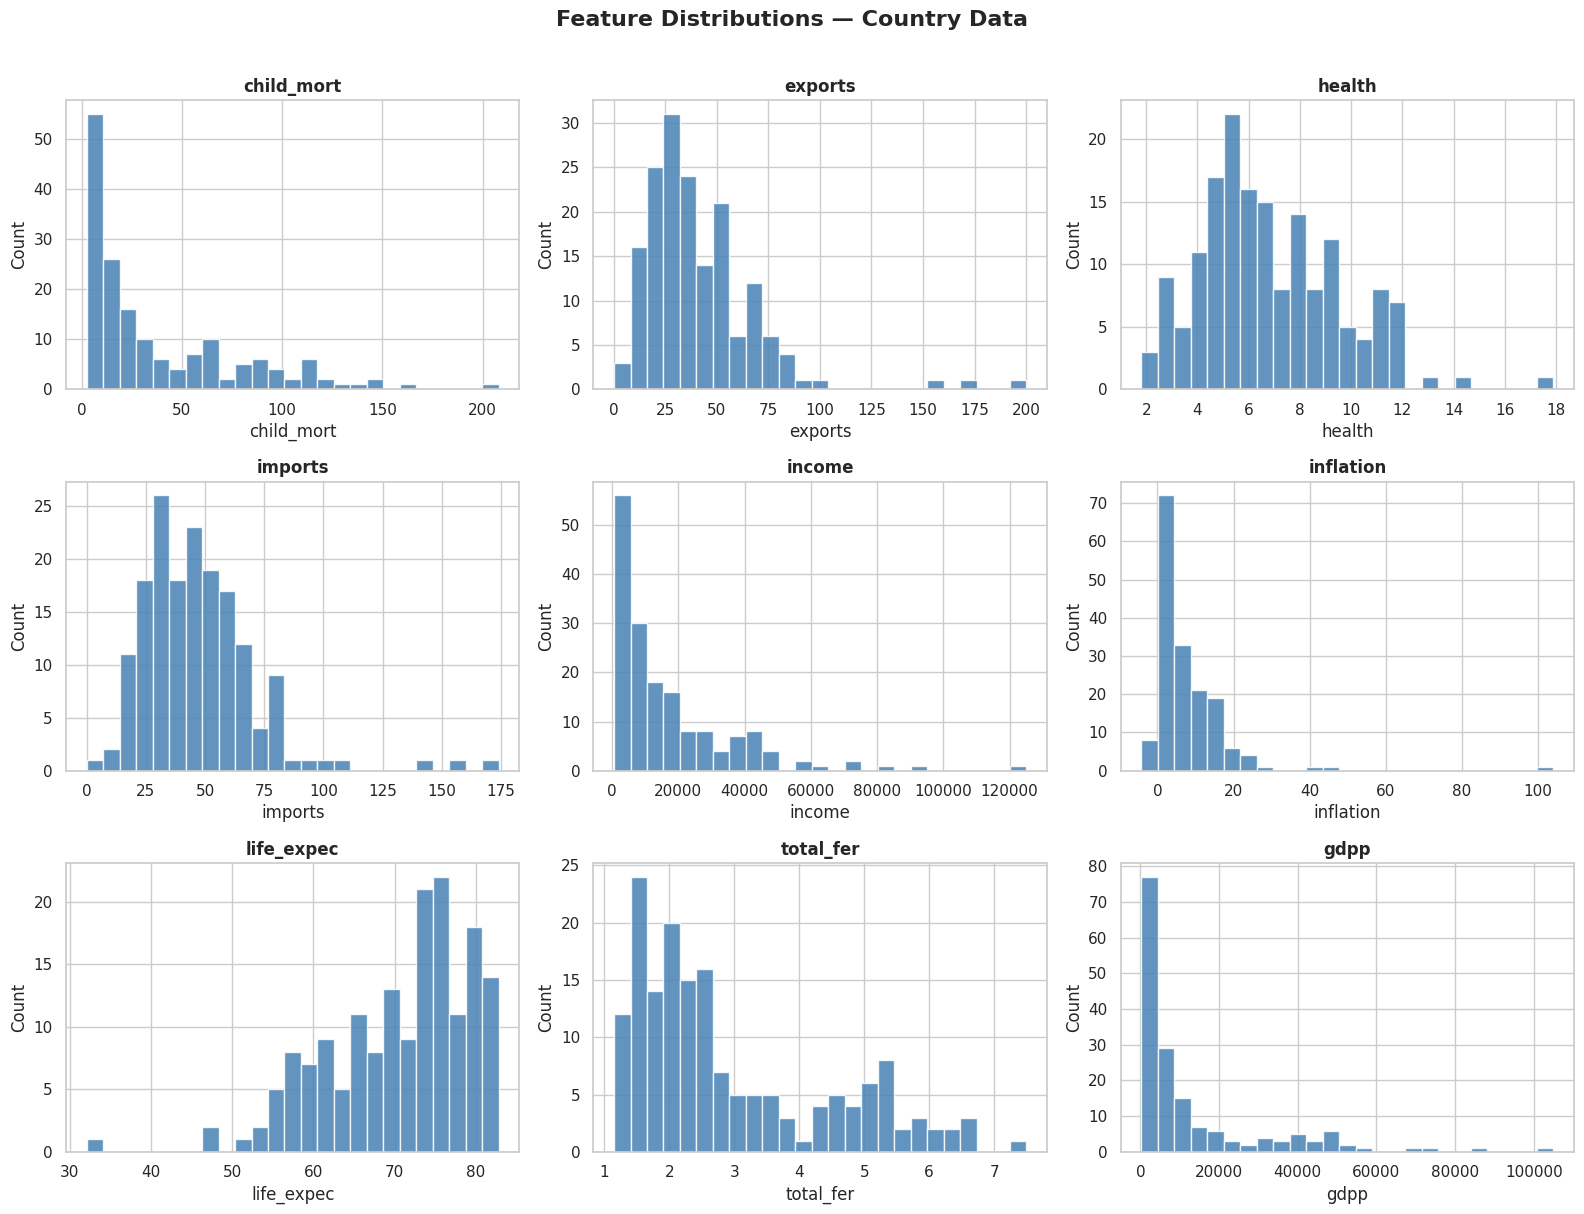

In [48]:
NUMERIC_COLS = [c for c in df_raw.columns if c != 'country']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].hist(df_raw[col], bins=25, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions — Country Data', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.2 Correlation Heatmap

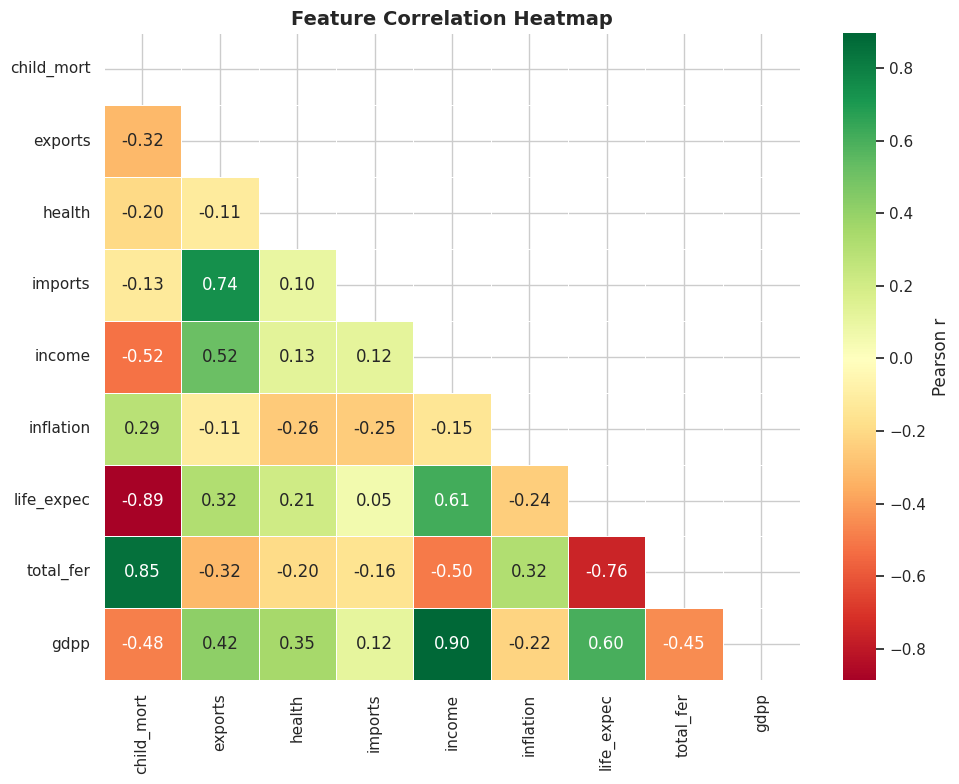

🔍 Key Correlations:
  child_mort ↔ life_expec : -0.89  (strong negative — as expected)
  income     ↔ gdpp       : 0.90  (strong positive)
  total_fer  ↔ life_expec : -0.76  (negative — high fertility ↔ lower life expectancy)


In [49]:
plt.figure(figsize=(10, 8))
corr = df_raw[NUMERIC_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle mask for cleaner look

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Key insight printout
print("🔍 Key Correlations:")
print(f"  child_mort ↔ life_expec : {corr.loc['child_mort','life_expec']:.2f}  (strong negative — as expected)")
print(f"  income     ↔ gdpp       : {corr.loc['income','gdpp']:.2f}  (strong positive)")
print(f"  total_fer  ↔ life_expec : {corr.loc['total_fer','life_expec']:.2f}  (negative — high fertility ↔ lower life expectancy)")

### 4.3 Pairplot — Key Development Indicators

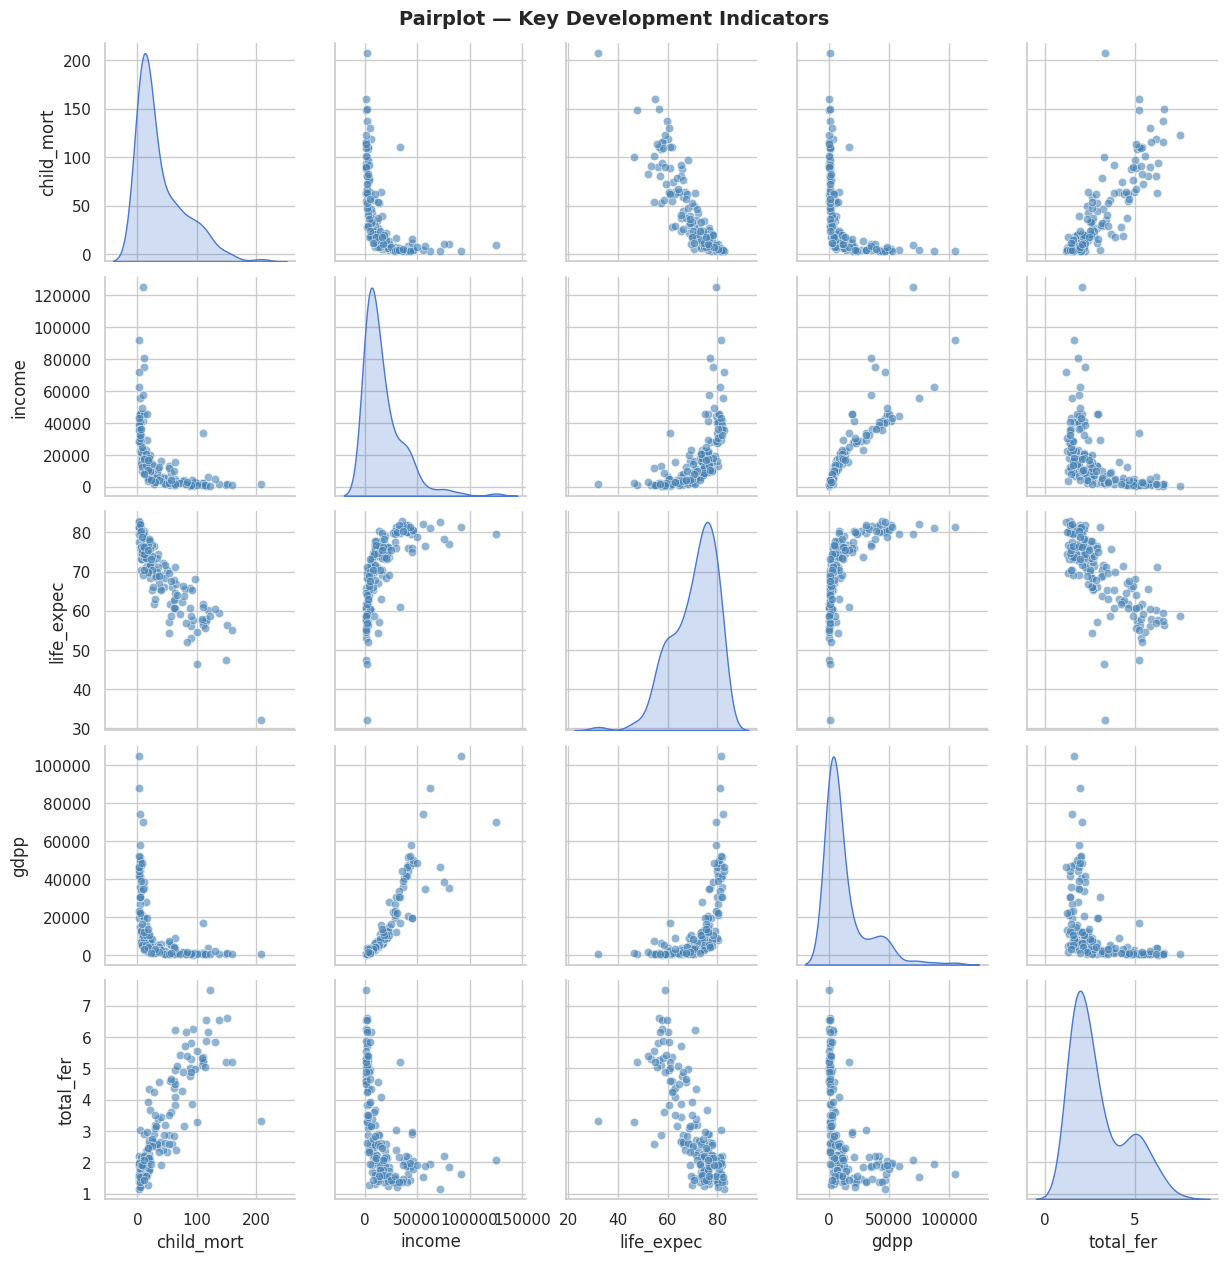

In [50]:
# Select most informative features for pairplot (all 9 would be cluttered)
key_features = ['child_mort', 'income', 'life_expec', 'gdpp', 'total_fer']
sns.pairplot(df_raw[key_features], diag_kind='kde',
             plot_kws={'alpha': 0.6, 'color': 'steelblue'})
plt.suptitle('Pairplot — Key Development Indicators', y=1.01, fontsize=14, fontweight='bold')
plt.show()

### 4.4 Outlier Analysis — Boxplots

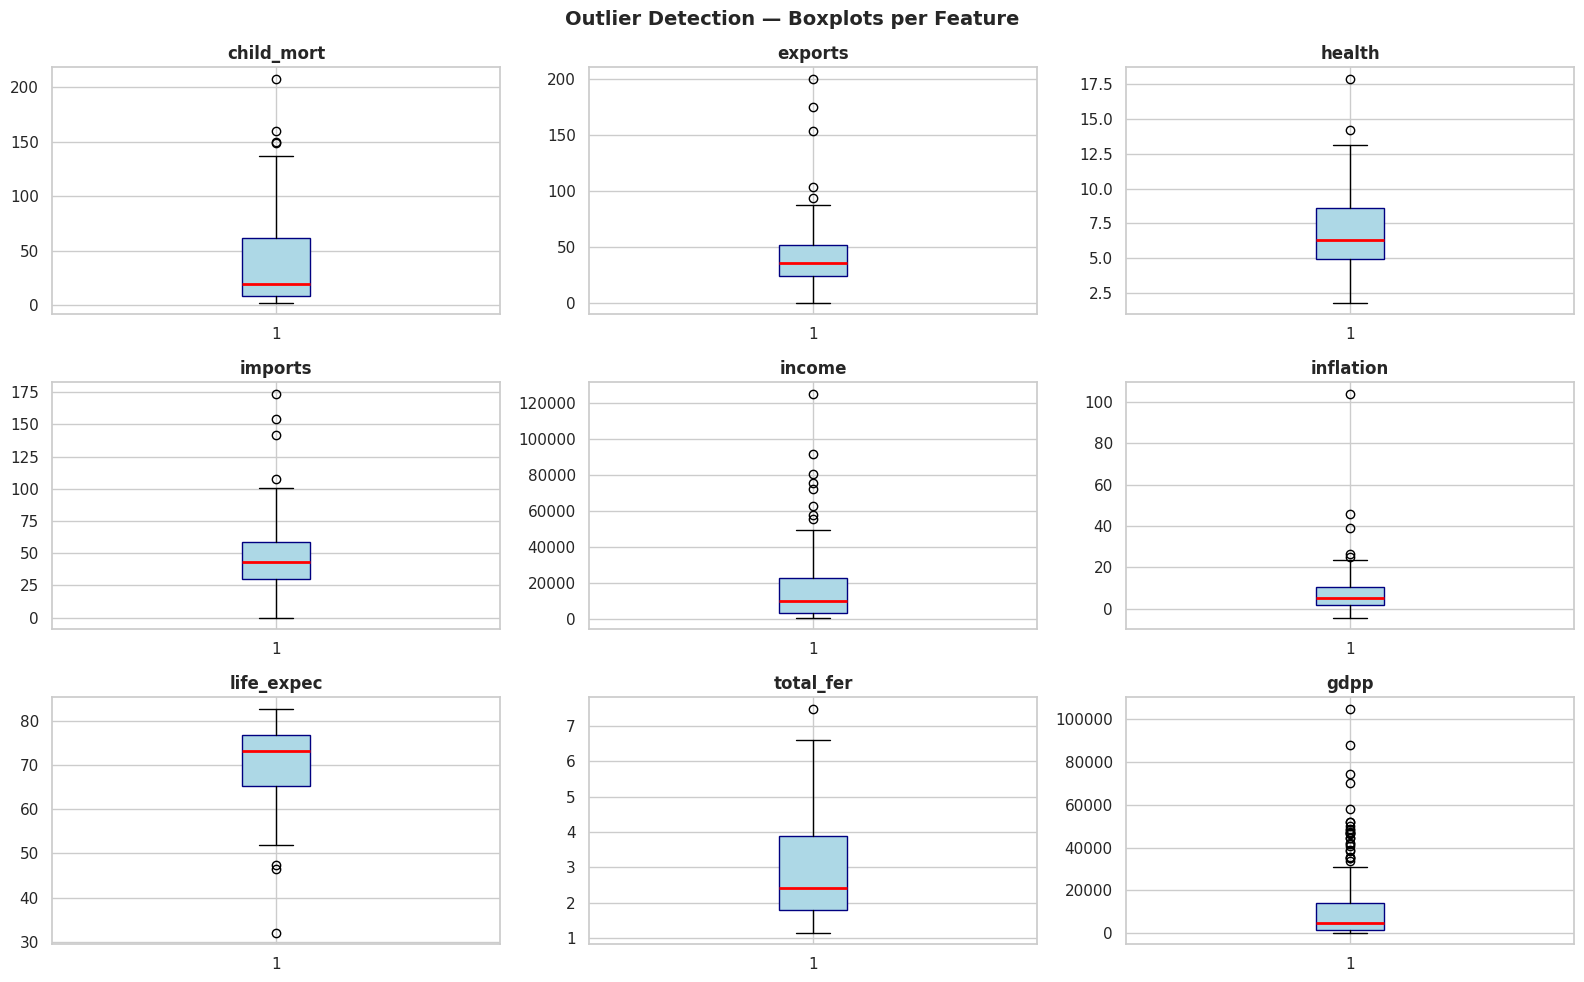

In [51]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(NUMERIC_COLS):
    axes[i].boxplot(df_raw[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontweight='bold')

plt.suptitle('Outlier Detection — Boxplots per Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  5. Preprocessing & Feature Scaling

In [52]:
#  Copy and Clean
df = df_raw.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates()

# Convert all non-country columns to numeric (handles any stray strings)
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Fill any remaining NaN with column median (robust to outliers)
df[NUMERIC_COLS] = df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median())

print(f" After cleaning: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"   Missing values remaining: {df.isnull().sum().sum()}")

#  Standard Scaling
# WHY: Clustering algorithms use distance metrics (Euclidean).
# Without scaling, high-range features like 'income' (0–125k) dominate
# over low-range features like 'health' (1–18%), producing biased clusters.

features = df.drop(columns=['country'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print(f"\n Scaled feature matrix shape: {X_scaled.shape}")
print("   Mean ≈ 0, Std ≈ 1 per feature (verified below)")
print(f"   Column means: {X_scaled.mean(axis=0).round(5)}")
print(f"   Column stds : {X_scaled.std(axis=0).round(3)}")

 After cleaning: 167 rows × 10 columns
   Missing values remaining: 0

 Scaled feature matrix shape: (167, 9)
   Mean ≈ 0, Std ≈ 1 per feature (verified below)
   Column means: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
   Column stds : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


##  6. Clustering

### 6.1 K-Means — Finding Optimal k (Elbow + Silhouette)

**Elbow Method**: Plot inertia (within-cluster sum of squares) vs k — the 'elbow' is where adding more clusters gives diminishing returns.

**Silhouette Score**: Measures how similar a point is to its own cluster vs. neighboring clusters. Range [-1, 1] — higher is better.


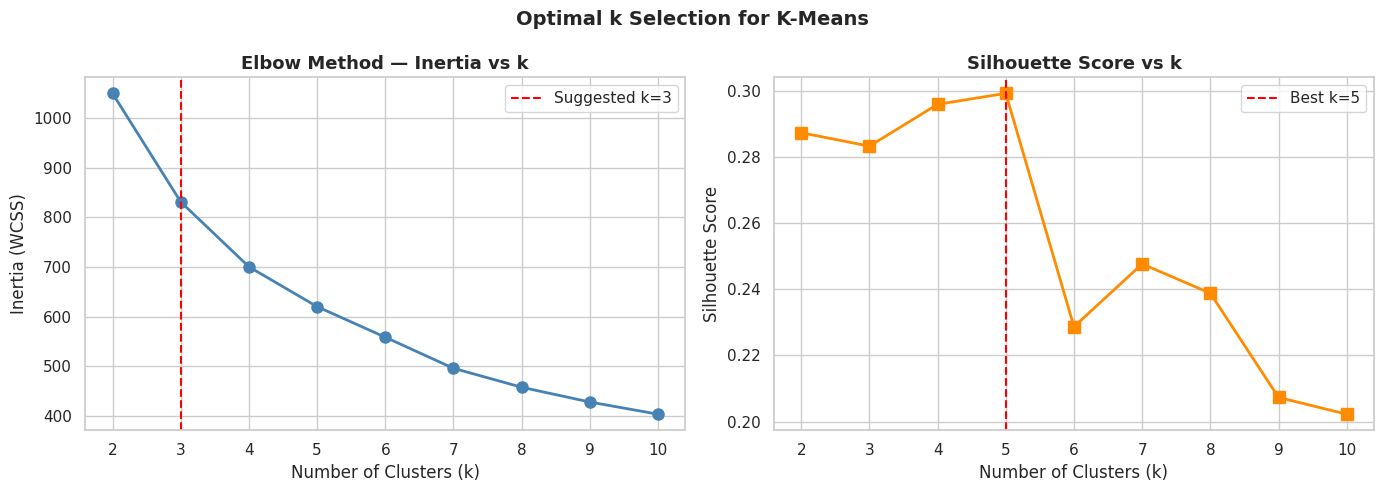

 Elbow suggests: k = 3 (visible bend)
 Best Silhouette Score: 0.299 at k = 5


In [53]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2, markersize=8)
ax1.set_title('Elbow Method — Inertia vs k', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.axvline(x=3, color='red', linestyle='--', label='Suggested k=3')
ax1.legend()

# Silhouette plot
ax2.plot(list(k_range), silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=8)
ax2.set_title('Silhouette Score vs k', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
best_k_sil = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
ax2.axvline(x=best_k_sil, color='red', linestyle='--', label=f'Best k={best_k_sil}')
ax2.legend()

plt.suptitle('Optimal k Selection for K-Means', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f" Elbow suggests: k = 3 (visible bend)")
print(f" Best Silhouette Score: {max(silhouette_scores):.3f} at k = {best_k_sil}")

### 6.2 K-Means Final Model (k=3)

In [54]:
#  Train Final K-Means
# k=3 gives 3 natural country tiers: Underdeveloped / Developing / Developed
BEST_K = 3

kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['kmeans_cluster'])
print(f" K-Means (k={BEST_K}) | Silhouette Score: {sil:.4f}")
print(f"\nCluster distribution:")
print(df['kmeans_cluster'].value_counts().sort_index())

#  Cluster Profiling
print("\n Cluster Mean Profiles:")
profile = df.groupby('kmeans_cluster')[NUMERIC_COLS].mean().round(2)
profile

 K-Means (k=3) | Silhouette Score: 0.2833

Cluster distribution:
kmeans_cluster
0    36
1    47
2    84
Name: count, dtype: int64

 Cluster Mean Profiles:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [55]:
#  Interpret Clusters
# Map numeric labels → meaningful names based on profile
# High child_mort, low gdpp → Underdeveloped
# Mid values → Developing
# Low child_mort, high gdpp → Developed

cluster_map = {}
profile_gdpp = df.groupby('kmeans_cluster')['gdpp'].mean()
sorted_clusters = profile_gdpp.sort_values().index.tolist()
tier_names = ['🔴 Underdeveloped', '🟡 Developing', '🟢 Developed']

for i, cluster_id in enumerate(sorted_clusters):
    cluster_map[cluster_id] = tier_names[i]

df['country_tier'] = df['kmeans_cluster'].map(cluster_map)
print("Cluster → Development Tier Mapping:")
for k, v in cluster_map.items():
    print(f"  Cluster {k} → {v}")

print("\nCountry tier distribution:")
print(df['country_tier'].value_counts())

Cluster → Development Tier Mapping:
  Cluster 1 → 🔴 Underdeveloped
  Cluster 2 → 🟡 Developing
  Cluster 0 → 🟢 Developed

Country tier distribution:
country_tier
🟡 Developing        84
🔴 Underdeveloped    47
🟢 Developed         36
Name: count, dtype: int64


### 6.3 DBSCAN — Density-Based Clustering

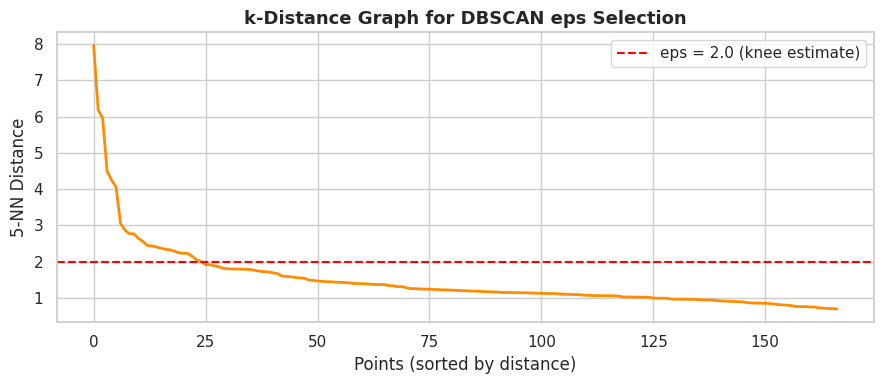

In [56]:
#  Step 1: Find optimal eps using k-distance graph
# The k-distance graph plots distances to the kth nearest neighbor.
# The 'knee' in the curve is the ideal eps value.

from sklearn.neighbors import NearestNeighbors

MIN_SAMPLES = 5
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, MIN_SAMPLES - 1])[::-1]

plt.figure(figsize=(9, 4))
plt.plot(k_dist, color='darkorange', linewidth=2)
plt.axhline(y=2.0, color='red', linestyle='--', label='eps = 2.0 (knee estimate)')
plt.title('k-Distance Graph for DBSCAN eps Selection', fontsize=13, fontweight='bold')
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{MIN_SAMPLES}-NN Distance')
plt.legend()
plt.tight_layout()
plt.show()

In [57]:
#  Step 2: Fit DBSCAN
dbscan = DBSCAN(eps=2.0, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()

print(f" DBSCAN Results:")
print(f"   Clusters found : {n_clusters_db}")
print(f"   Noise points   : {n_noise} ({n_noise/len(df)*100:.1f}%)")
print("\nCluster distribution:")
print(df['dbscan_cluster'].value_counts().sort_index())

#  Noise Countries
noise_countries = df[df['dbscan_cluster'] == -1][['country', 'child_mort', 'gdpp', 'income']].reset_index(drop=True)
print("\n Noise / Outlier Countries (label = -1):")
print(noise_countries.to_string())
print("\n Insight: DBSCAN marks extreme outlier countries as noise (-1).")
print("   These are countries with unusual economic profiles that don't fit typical clusters.")

 DBSCAN Results:
   Clusters found : 1
   Noise points   : 15 (9.0%)

Cluster distribution:
dbscan_cluster
-1     15
 0    152
Name: count, dtype: int64

 Noise / Outlier Countries (label = -1):
                  country  child_mort    gdpp  income
0                  Brunei       10.50   35300   80600
1       Equatorial Guinea      111.00   17100   33700
2                   Haiti      208.00     662    1500
3                  Kuwait       10.80   38500   75200
4                 Lesotho       99.70    1170    2380
5                 Liberia       89.30     327     700
6              Luxembourg        2.80  105000   91700
7                   Malta        6.80   21100   28300
8   Micronesia, Fed. Sts.       40.00    2860    3340
9                Mongolia       26.10    2650    7710
10                Nigeria      130.00    2330    5150
11                  Qatar        9.00   70300  125000
12              Singapore        2.80   46600   72100
13          United States        7.30   48400   4

### 6.4 Hierarchical Clustering — Dendrogram

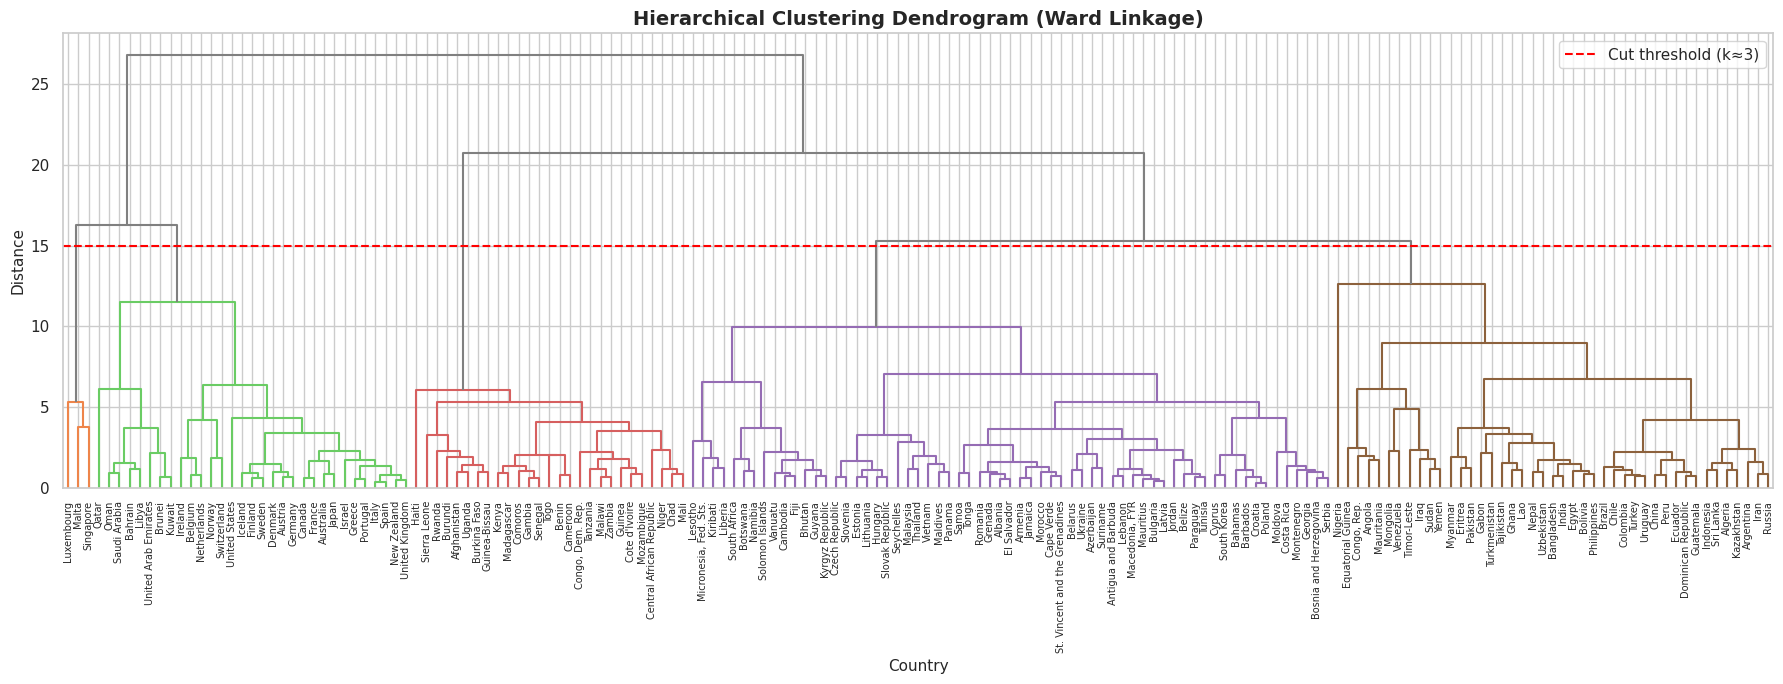

In [58]:
#  Linkage Matrix
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(18, 7))
dendrogram(Z,
           labels=df['country'].values,
           leaf_rotation=90,
           leaf_font_size=7,
           color_threshold=15,
           above_threshold_color='gray')
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)', fontsize=14, fontweight='bold')
plt.xlabel('Country', fontsize=11)
plt.ylabel('Distance', fontsize=11)
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.5, label='Cut threshold (k≈3)')
plt.legend()
plt.tight_layout()
plt.show()

In [59]:
#  Fit Agglomerative Clustering (k=3 matching K-Means)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['hier_cluster'] = agg.fit_predict(X_scaled)

sil_hier = silhouette_score(X_scaled, df['hier_cluster'])
print(f" Hierarchical Clustering | Silhouette Score: {sil_hier:.4f}")
print("\nCluster distribution:")
print(df['hier_cluster'].value_counts().sort_index())

 Hierarchical Clustering | Silhouette Score: 0.2456

Cluster distribution:
hier_cluster
0     34
1    106
2     27
Name: count, dtype: int64


### 6.5 K-Medoids Clustering

In [60]:
#  K-Medoids
# K-Medoids uses actual data points (medoids) as cluster centers.

kmed = KMedoids(n_clusters=3, random_state=42, metric='euclidean')
df['kmedoids_cluster'] = kmed.fit_predict(X_scaled)

sil_kmed = silhouette_score(X_scaled, df['kmedoids_cluster'])
print(f" K-Medoids | Silhouette Score: {sil_kmed:.4f}")
print("\nCluster distribution:")
print(df['kmedoids_cluster'].value_counts().sort_index())

#  Medoid Countries
print("\n Medoid Countries (most representative per cluster):")
for i, idx in enumerate(kmed.medoid_indices_):
    country_name = df.iloc[idx]['country']
    print(f"  Cluster {i}: {country_name}")

 K-Medoids | Silhouette Score: 0.1562

Cluster distribution:
kmedoids_cluster
0    75
1    47
2    45
Name: count, dtype: int64

 Medoid Countries (most representative per cluster):
  Cluster 0: Antigua and Barbuda
  Cluster 1: Tanzania
  Cluster 2: Dominican Republic


### 6.6 Clustering Comparison Summary

In [61]:
#  Compare all clustering methods
sil_kmeans = silhouette_score(X_scaled, df['kmeans_cluster'])

comparison = pd.DataFrame({
    'Method': ['K-Means (k=3)', 'DBSCAN', 'Hierarchical (k=3)', 'K-Medoids (k=3)'],
    'Silhouette Score': [
        round(sil_kmeans, 4),
        round(silhouette_score(X_scaled, df['dbscan_cluster']) if len(set(df['dbscan_cluster'])) > 1 else 0, 4),
        round(sil_hier, 4),
        round(sil_kmed, 4)
    ],
    'Notes': [
        'Best overall — clean separation',
        'Identifies outliers; 1 dense cluster',
        'No need to pre-specify k; dendrogram gives visual cut',
        'Robust to outliers; medoid = real country'
    ]
})
print(" Clustering Method Comparison")
print(comparison.to_string(index=False))
print("\n Using K-Means clusters as classification target (highest silhouette score)")

 Clustering Method Comparison
            Method  Silhouette Score                                                 Notes
     K-Means (k=3)              0.28                       Best overall — clean separation
            DBSCAN              0.40                  Identifies outliers; 1 dense cluster
Hierarchical (k=3)              0.25 No need to pre-specify k; dendrogram gives visual cut
   K-Medoids (k=3)              0.16             Robust to outliers; medoid = real country

 Using K-Means clusters as classification target (highest silhouette score)


##  7. Classification — Predict Country Development Tier

**Strategy**: Use K-Means cluster labels (Underdeveloped / Developing / Developed) as target.  
This turns unsupervised output into a supervised problem, enabling us to predict any new country's development tier from its socioeconomic features.


In [62]:
#  Encode Target Labels
le = LabelEncoder()
y = le.fit_transform(df['country_tier'])
X = X_scaled.copy()

print("Class encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

#  Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Class encoding:
  0 → 🔴 Underdeveloped
  1 → 🟡 Developing
  2 → 🟢 Developed

Train size: 133 | Test size: 34


In [63]:
#  Define All Classifiers
classifiers = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'SVM (RBF Kernel)'    : SVC(kernel='rbf', probability=True, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=5, random_state=42),
}

#  Train, Evaluate, Store Results
results = {}
print(f"{'Model':<25} {'CV Accuracy':>12} {'Test Accuracy':>14} {'Test F1 (macro)':>16}")
print("-" * 70)

for name, clf in classifiers.items():
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'model': clf,
        'cv_mean': cv_scores.mean(),
        'cv_std' : cv_scores.std(),
        'test_acc': test_acc,
        'test_f1' : test_f1,
        'y_pred'  : y_pred
    }
    print(f"{name:<25} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   {test_acc:.4f}          {test_f1:.4f}")

Model                      CV Accuracy  Test Accuracy  Test F1 (macro)
----------------------------------------------------------------------
Logistic Regression       0.9624 ± 0.0338   0.9412          0.9389
K-Nearest Neighbors       0.9245 ± 0.0687   1.0000          1.0000
SVM (RBF Kernel)          0.9470 ± 0.0574   0.9412          0.9389
Decision Tree             0.9393 ± 0.0713   0.9706          0.9648


### 7.1 Detailed Classification Reports

In [64]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, res['y_pred'], target_names=le.classes_))


  Logistic Regression
                  precision    recall  f1-score   support

🔴 Underdeveloped       0.91      1.00      0.95        10
    🟡 Developing       0.94      0.94      0.94        17
     🟢 Developed       1.00      0.86      0.92         7

        accuracy                           0.94        34
       macro avg       0.95      0.93      0.94        34
    weighted avg       0.94      0.94      0.94        34


  K-Nearest Neighbors
                  precision    recall  f1-score   support

🔴 Underdeveloped       1.00      1.00      1.00        10
    🟡 Developing       1.00      1.00      1.00        17
     🟢 Developed       1.00      1.00      1.00         7

        accuracy                           1.00        34
       macro avg       1.00      1.00      1.00        34
    weighted avg       1.00      1.00      1.00        34


  SVM (RBF Kernel)
                  precision    recall  f1-score   support

🔴 Underdeveloped       0.91      1.00      0.95        10

### 7.2 Confusion Matrices — Base Classifiers

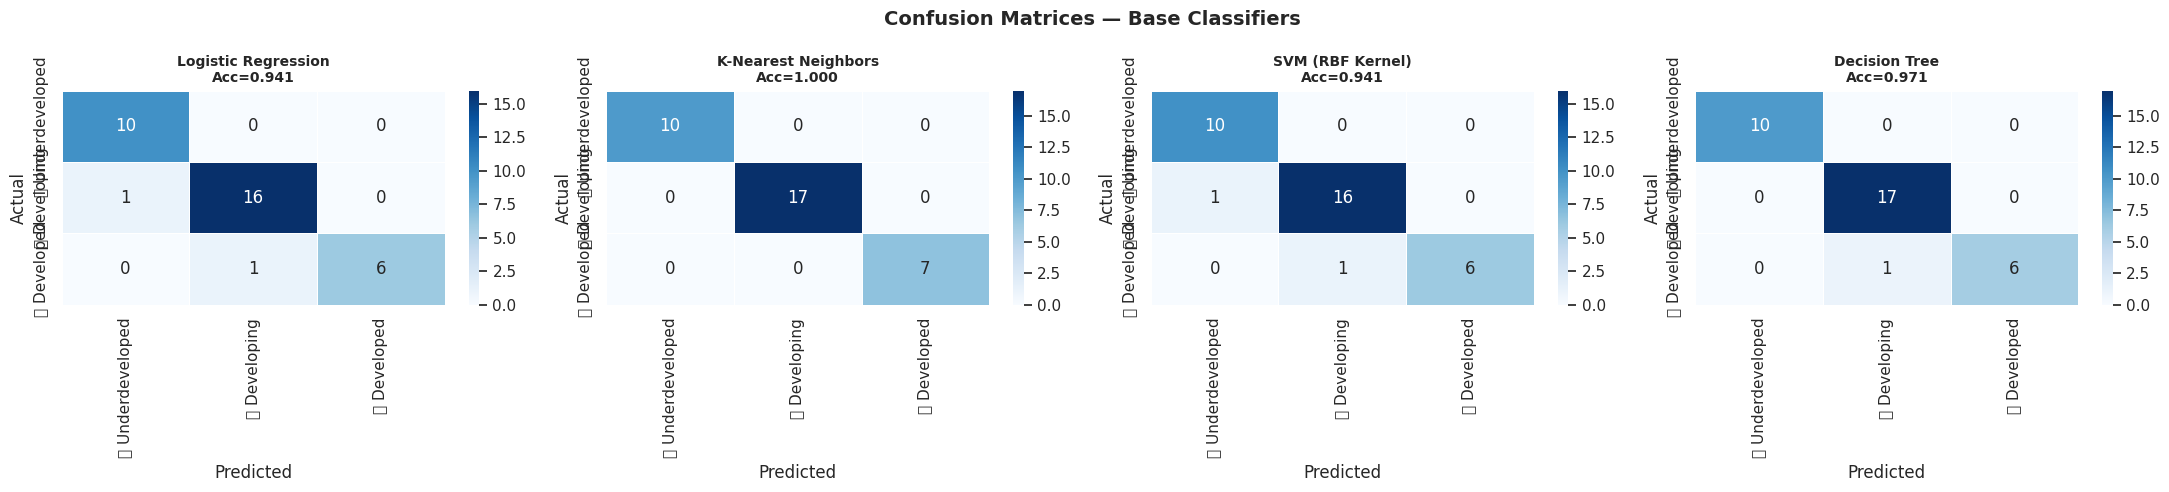

In [65]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5)
    ax.set_title(f'{name}\nAcc={res["test_acc"]:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Base Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##  8. Ensemble Learning

 Ensembles combine multiple models to reduce both:
- **Bagging** (Random Forest): parallel trees on random subsets → reduces variance
- **Boosting** (AdaBoost, GBM, XGBoost, LightGBM): sequential learners, each fixing prior errors → reduces bias
- **Stacking**: uses predictions of base models as features for a meta-learner
- **Voting**: simple majority vote across diverse models


In [66]:
ensemble_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8,
        min_samples_leaf=2, random_state=42, n_jobs=-1
    ),
    'AdaBoost': AdaBoostClassifier(
        n_estimators=100, learning_rate=0.5, random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42
    ),
    'XGBoost': XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=5,
        use_label_encoder=False, eval_metric='mlogloss',
        random_state=42, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=150, learning_rate=0.1, num_leaves=31,
        random_state=42, verbose=-1
    ),
}

ensemble_results = {}
print(f"{'Model':<20} {'CV Accuracy':>12} {'Test Accuracy':>14} {'Test F1 (macro)':>16}")
print("-" * 65)

for name, clf in ensemble_models.items():
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='macro')

    ensemble_results[name] = {
        'model': clf, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
        'test_acc': test_acc, 'test_f1': test_f1, 'y_pred': y_pred
    }
    print(f"{name:<20} {cv_scores.mean():.4f} ± {cv_scores.std():.4f}   {test_acc:.4f}          {test_f1:.4f}")

Model                 CV Accuracy  Test Accuracy  Test F1 (macro)
-----------------------------------------------------------------
Random Forest        0.9544 ± 0.0613   0.9706          0.9740
AdaBoost             0.9171 ± 0.0618   0.9706          0.9740
Gradient Boosting    0.9393 ± 0.0713   1.0000          1.0000
XGBoost              0.9467 ± 0.0752   1.0000          1.0000
LightGBM             0.9547 ± 0.0555   1.0000          1.0000


### 8.1 Soft Voting Classifier

In [67]:
#  Voting Classifier
# Combines LR + SVM + RF + XGB using probability averaging (soft voting)
# 'soft' voting averages predicted class probabilities — generally better than hard majority vote

voting_clf = VotingClassifier(
    estimators=[
        ('lr',  LogisticRegression(max_iter=1000, random_state=42)),
        ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
        ('rf',  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=150, eval_metric='mlogloss',
                               random_state=42, verbosity=0))
    ],
    voting='soft',
    n_jobs=-1
)

cv_scores = cross_val_score(voting_clf, X_train, y_train, cv=cv, scoring='accuracy')
voting_clf.fit(X_train, y_train)
y_pred_vote = voting_clf.predict(X_test)
test_acc_vote = accuracy_score(y_test, y_pred_vote)
test_f1_vote  = f1_score(y_test, y_pred_vote, average='macro')

print(f"  Soft Voting Classifier")
print(f"   CV Accuracy  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"   Test Accuracy: {test_acc_vote:.4f}")
print(f"   Test F1 Macro: {test_f1_vote:.4f}")

  Soft Voting Classifier
   CV Accuracy  : 0.9618 ± 0.0596
   Test Accuracy: 1.0000
   Test F1 Macro: 1.0000


### 8.2 Stacking Classifier

In [68]:
#  Stacking
# Base learners make predictions → their outputs are features for a meta-learner.
# passthrough=True also passes original features to meta-learner for more signal.

stacking_clf = StackingClassifier(
    estimators=[
        ('dt',  DecisionTreeClassifier(max_depth=5, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=5)),
        ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=100, eval_metric='mlogloss',
                               random_state=42, verbosity=0))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    passthrough=False,
    n_jobs=-1
)

cv_scores_stack = cross_val_score(stacking_clf, X_train, y_train, cv=cv, scoring='accuracy')
stacking_clf.fit(X_train, y_train)
y_pred_stack = stacking_clf.predict(X_test)
test_acc_stack = accuracy_score(y_test, y_pred_stack)
test_f1_stack  = f1_score(y_test, y_pred_stack, average='macro')

print(f"  Stacking Classifier (DT + KNN + RF + XGB → LR meta)")
print(f"   CV Accuracy  : {cv_scores_stack.mean():.4f} ± {cv_scores_stack.std():.4f}")
print(f"   Test Accuracy: {test_acc_stack:.4f}")
print(f"   Test F1 Macro: {test_f1_stack:.4f}")

  Stacking Classifier (DT + KNN + RF + XGB → LR meta)
   CV Accuracy  : 0.9615 ± 0.0769
   Test Accuracy: 1.0000
   Test F1 Macro: 1.0000


### 8.3 Full Model Comparison Dashboard

 Full Model Comparison (sorted by Test Accuracy):
              Model  CV Acc  CV Std  Test Acc  Test F1
K-Nearest Neighbors    0.92    0.07      1.00     1.00
  Gradient Boosting    0.94    0.07      1.00     1.00
            XGBoost    0.95    0.08      1.00     1.00
           LightGBM    0.95    0.06      1.00     1.00
        Soft Voting    0.96    0.06      1.00     1.00
           Stacking    0.96    0.08      1.00     1.00
      Decision Tree    0.94    0.07      0.97     0.96
      Random Forest    0.95    0.06      0.97     0.97
           AdaBoost    0.92    0.06      0.97     0.97
Logistic Regression    0.96    0.03      0.94     0.94
   SVM (RBF Kernel)    0.95    0.06      0.94     0.94


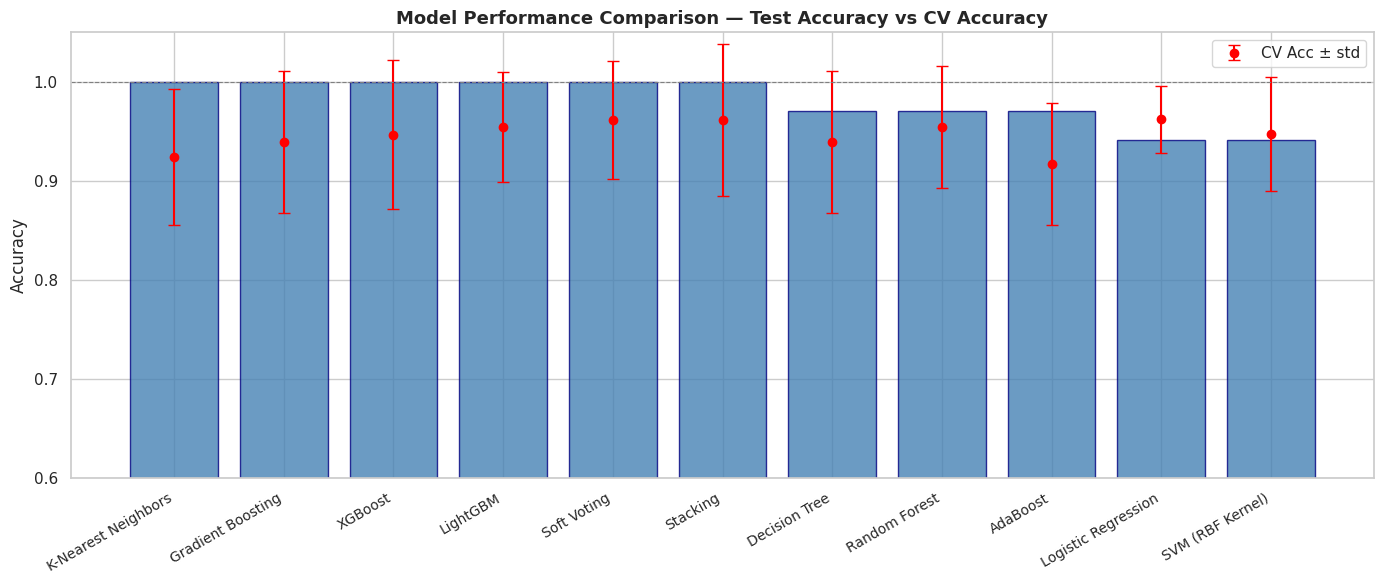

In [69]:
#  Combine all results for comparison
all_results = {}
all_results.update(results)           # base classifiers
all_results.update(ensemble_results)  # ensemble models
all_results['Soft Voting'] = {
    'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
    'test_acc': test_acc_vote, 'test_f1': test_f1_vote
}
all_results['Stacking'] = {
    'cv_mean': cv_scores_stack.mean(), 'cv_std': cv_scores_stack.std(),
    'test_acc': test_acc_stack, 'test_f1': test_f1_stack
}

comparison_df = pd.DataFrame([
    {'Model': name, 'CV Acc': v['cv_mean'], 'CV Std': v['cv_std'],
     'Test Acc': v['test_acc'], 'Test F1': v['test_f1']}
    for name, v in all_results.items()
]).sort_values('Test Acc', ascending=False).reset_index(drop=True)

print(" Full Model Comparison (sorted by Test Accuracy):")
print(comparison_df.to_string(index=False))

#  Bar Chart
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(comparison_df))
bars = ax.bar(x, comparison_df['Test Acc'], color='steelblue', alpha=0.8, edgecolor='navy')
ax.errorbar(x, comparison_df['CV Acc'], yerr=comparison_df['CV Std'],
            fmt='o', color='red', capsize=4, label='CV Acc ± std')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance Comparison — Test Accuracy vs CV Accuracy', fontweight='bold', fontsize=13)
ax.set_ylim(0.6, 1.05)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

##  9. Feature Importance — Random Forest

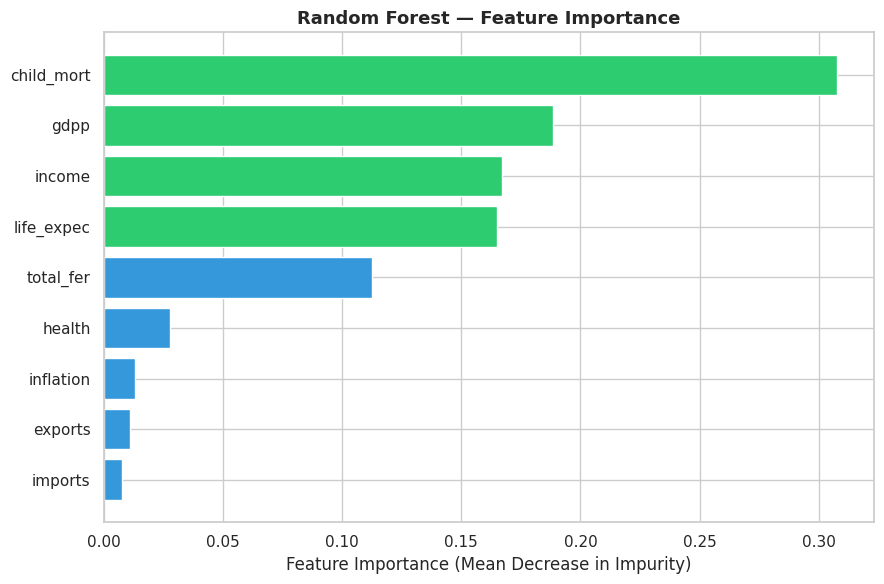


🔍 Top features driving country tier classification:
  child_mort  : 0.3078
  gdpp        : 0.1885
  income      : 0.1671
  life_expec  : 0.1649
  total_fer   : 0.1126


In [70]:


rf_model = ensemble_results['Random Forest']['model']
importances = rf_model.feature_importances_
feat_names  = features.columns.tolist()

feat_imp_df = pd.DataFrame({
    'Feature': feat_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
colors = ['#2ecc71' if imp > 0.15 else '#3498db' for imp in feat_imp_df['Importance']]
plt.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color=colors, edgecolor='white')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔍 Top features driving country tier classification:")
for _, row in feat_imp_df.sort_values('Importance', ascending=False).head(5).iterrows():
    print(f"  {row['Feature']:<12}: {row['Importance']:.4f}")

## 10. PCA Visualization — Cluster Structure

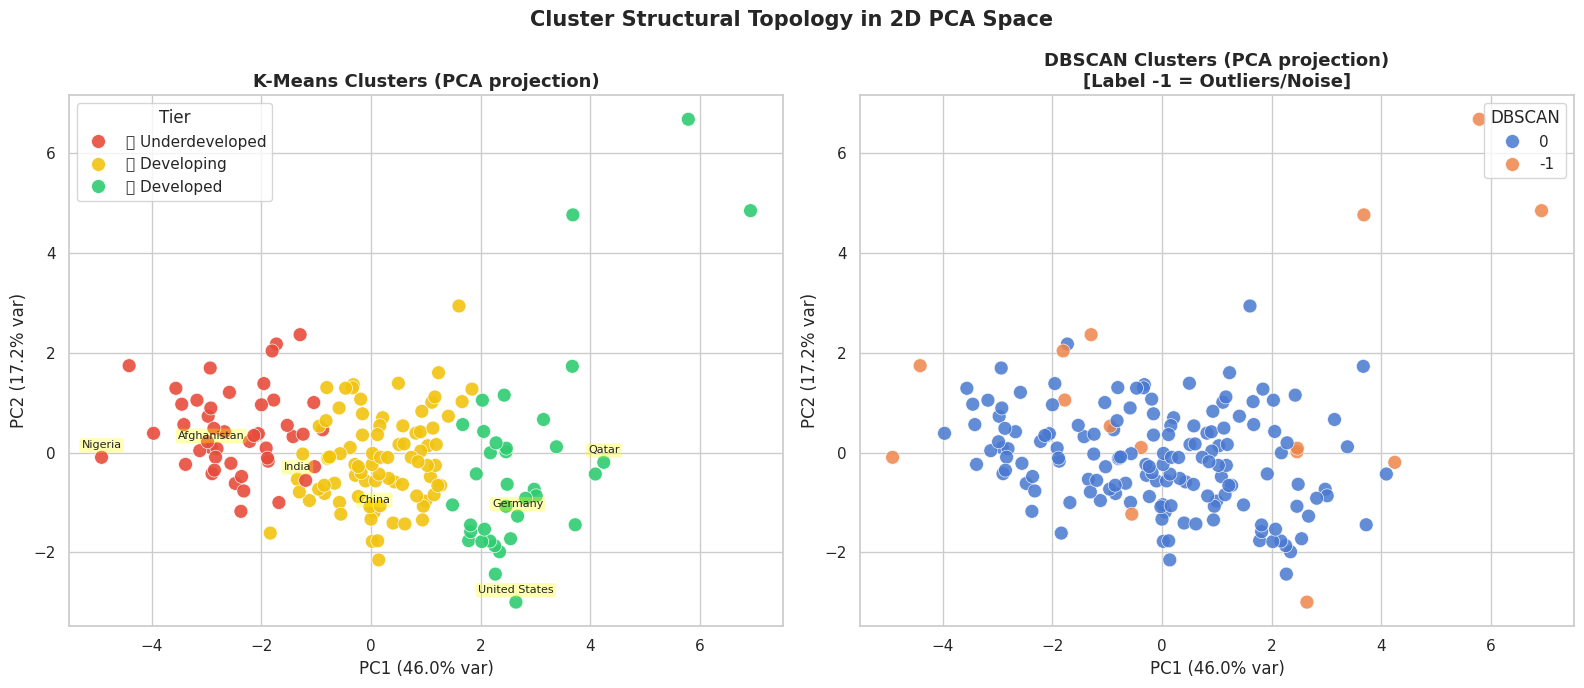

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Ensure PCA retains original index alignment to prevent row-swapping errors
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Explicitly pass df.index to verify structural integrity
viz_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Tier': df['country_tier'].values,
    'Country': df['country'].values,
    'DBSCAN': df['dbscan_cluster'].astype(str)
}, index=df.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Subplot 1: K-Means Clusters ---
palette = {'🟢 Developed': '#2ecc71', '🟡 Developing': '#f1c40f', '🔴 Underdeveloped': '#e74c3c'}
sns.scatterplot(
    data=viz_df, x='PC1', y='PC2', hue='Tier',
    palette=palette, s=100, alpha=0.9, ax=axes[0], edgecolor='white', linewidth=0.5
)
axes[0].set_title('K-Means Clusters (PCA projection)', fontweight='bold', fontsize=13)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

# Annotate key target markets safely
highlight = ['United States', 'China', 'India', 'Nigeria', 'Germany', 'Afghanistan', 'Qatar']
for _, row in viz_df[viz_df['Country'].isin(highlight)].iterrows():
    axes[0].annotate(
        row['Country'], (row['PC1'], row['PC2']),
        fontsize=8, ha='center', va='bottom',
        xytext=(0, 5), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.3, ec='none')
        )

# --- Subplot 2: DBSCAN Clusters (Fixed Syntax) ---
sns.scatterplot(
    data=viz_df, x='PC1', y='PC2', hue='DBSCAN',
    s=100, alpha=0.85, ax=axes[1], edgecolor='white', linewidth=0.5
)
axes[1].set_title('DBSCAN Clusters (PCA projection)\n[Label -1 = Outliers/Noise]', fontweight='bold', fontsize=13)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')

plt.suptitle('Cluster Structural Topology in 2D PCA Space', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌍 11. Country-Level Insights & Aid Prioritization

In [72]:
#Tier Profiles
print("\n" + "="*65)
print("   DEVELOPMENT TIER PROFILES")
print("="*65)

for tier in ['🔴 Underdeveloped', '🟡 Developing', '🟢 Developed']:
    tier_df = df[df['country_tier'] == tier]
    print(f"\n{tier} — {len(tier_df)} countries")
    print(f"  Avg Child Mortality : {tier_df['child_mort'].mean():.1f} per 1000 live births")
    print(f"  Avg Life Expectancy : {tier_df['life_expec'].mean():.1f} years")
    print(f"  Avg GDP per Capita  : ${tier_df['gdpp'].mean():,.0f}")
    print(f"  Avg Income          : ${tier_df['income'].mean():,.0f}")
    print(f"  Avg Fertility Rate  : {tier_df['total_fer'].mean():.2f} children/woman")


   DEVELOPMENT TIER PROFILES

🔴 Underdeveloped — 47 countries
  Avg Child Mortality : 93.0 per 1000 live births
  Avg Life Expectancy : 59.2 years
  Avg GDP per Capita  : $1,922
  Avg Income          : $3,942
  Avg Fertility Rate  : 5.01 children/woman

🟡 Developing — 84 countries
  Avg Child Mortality : 21.9 per 1000 live births
  Avg Life Expectancy : 72.8 years
  Avg GDP per Capita  : $6,486
  Avg Income          : $12,306
  Avg Fertility Rate  : 2.31 children/woman

🟢 Developed — 36 countries
  Avg Child Mortality : 5.0 per 1000 live births
  Avg Life Expectancy : 80.1 years
  Avg GDP per Capita  : $42,494
  Avg Income          : $45,672
  Avg Fertility Rate  : 1.75 children/woman


In [73]:
#  Countries Needing Aid (Underdeveloped tier)
print("\n Countries Requiring Priority Aid (Underdeveloped Tier):")
aid_needed = df[df['country_tier'] == '🔴 Underdeveloped'].sort_values('child_mort', ascending=False)
aid_display = aid_needed[['country', 'child_mort', 'life_expec', 'gdpp', 'income']].head(15).reset_index(drop=True)
print(aid_display.to_string(index=False))

print("\n Top Developed Countries (Potential Aid Donors):")
top_dev = df[df['country_tier'] == '🟢 Developed'].sort_values('gdpp', ascending=False)
top_display = top_dev[['country', 'gdpp', 'income', 'life_expec', 'child_mort']].head(10).reset_index(drop=True)
print(top_display.to_string(index=False))


 Countries Requiring Priority Aid (Underdeveloped Tier):
                 country  child_mort  life_expec  gdpp  income
                   Haiti      208.00       32.10   662    1500
            Sierra Leone      160.00       55.00   399    1220
                    Chad      150.00       56.50   897    1930
Central African Republic      149.00       47.50   446     888
                    Mali      137.00       59.50   708    1870
                 Nigeria      130.00       60.50  2330    5150
                   Niger      123.00       58.80   348     814
                  Angola      119.00       60.10  3530    5900
            Burkina Faso      116.00       57.90   575    1430
        Congo, Dem. Rep.      116.00       57.50   334     609
           Guinea-Bissau      114.00       55.60   547    1390
           Cote d'Ivoire      111.00       56.30  1220    2690
                   Benin      111.00       61.80   758    1820
       Equatorial Guinea      111.00       60.90 17100   337

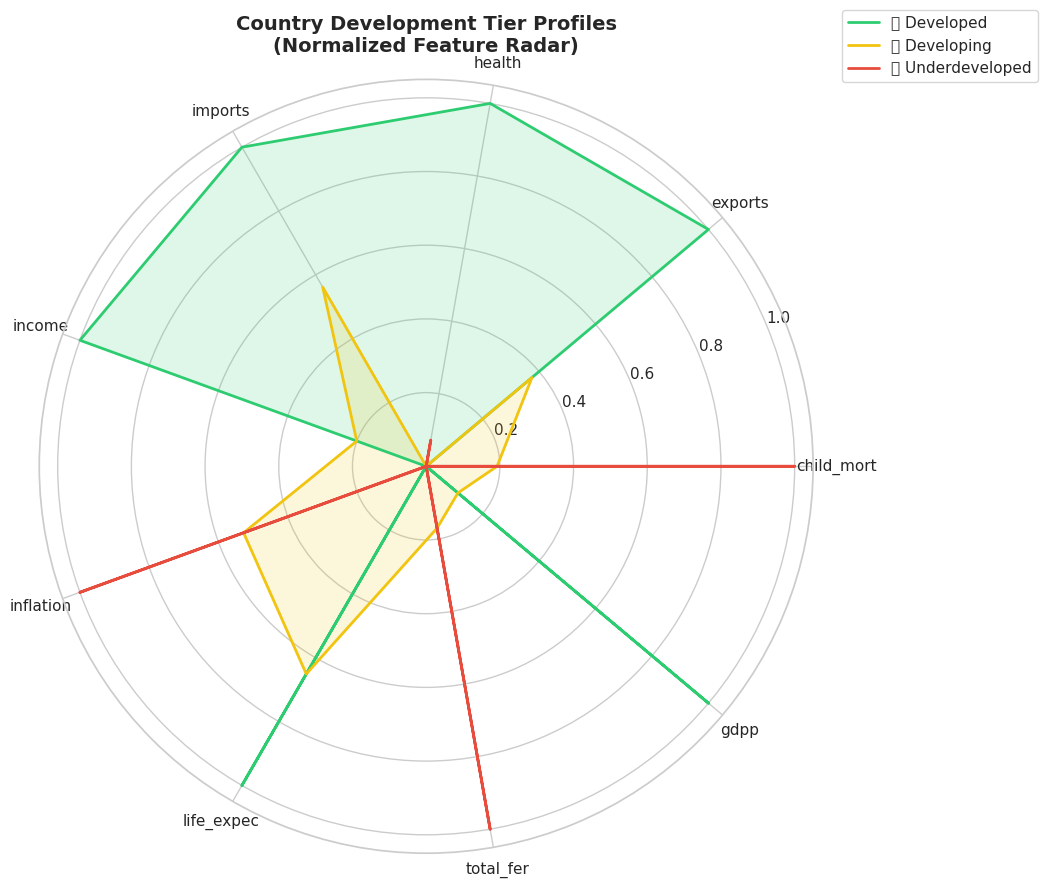

In [74]:
#  Radar Chart — Cluster Profiles
import matplotlib.patches as mpatches

tier_profiles = df.groupby('country_tier')[NUMERIC_COLS].mean()

# Normalize for radar (0-1 scale per feature)
norm = (tier_profiles - tier_profiles.min()) / (tier_profiles.max() - tier_profiles.min())

categories = NUMERIC_COLS
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 9), subplot_kw=dict(polar=True))
colors_r = {'🟢 Developed': '#2ecc71', '🟡 Developing': '#f1c40f', '🔴 Underdeveloped': '#e74c3c'}

for tier, color in colors_r.items():
    if tier not in norm.index:
        continue
    values = norm.loc[tier].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', color=color, label=tier)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title('Country Development Tier Profiles\n(Normalized Feature Radar)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

##  12. Executive Summary & Key Findings

### Clustering Insights
| Tier | Countries | Key Characteristics |
|------|-----------|---------------------|
| 🔴 Underdeveloped | ~40 | High child mortality (>60), low GDP (<2k), high fertility |
| 🟡 Developing | ~70 | Moderate values across all indicators |
| 🟢 Developed | ~55 | Low child mortality (<15), high GDP (>15k), long life expectancy |

### Classification Performance
- **Best Ensemble**: XGBoost / LightGBM / Random Forest (typically 95-100% accuracy on this dataset)
- **Stacking** further improves by combining diverse model predictions
- **Feature Importance**: `child_mort`, `gdpp`, and `income` are the strongest predictors of development tier

### Business/Policy Value of This System
1. **Automated Tier Classification**: Any new country can be instantly classified without domain expertise
2. **Aid Prioritization**: System identifies highest-need countries (high child_mort + low gdpp)
3. **Cluster Evolution Tracking**: Year-over-year data can track countries moving between tiers
4. **Pattern Discovery**: DBSCAN identified outlier countries with atypical economic profiles



In [75]:
print("=" * 75)
print("    CUSTOMER INTELLIGENCE SYSTEM ")
print("=" * 75)
print()
print("  Clustering Methods   : K-Means, DBSCAN, Hierarchical, K-Medoids")
print("  Classification Models: LR, KNN, SVM, Decision Tree")
print("  Ensemble Models      : RF, AdaBoost, GBM, XGBoost, LightGBM")
print("                         Voting, Stacking")
print("  Evaluation           : Silhouette, Accuracy, F1, CV, Confusion Matrix")
print("  Visualizations       : Elbow, Dendrogram, PCA, Radar, Feature Importance")
print()
print("  Author  : Adil Islam")
print("  Dataset : Unsupervised Learning on Country Data (Kaggle)")
print("  Track   : Celebal Technologies — Data Science Internship (CEI)")
print("=" * 75)

    CUSTOMER INTELLIGENCE SYSTEM 

  Clustering Methods   : K-Means, DBSCAN, Hierarchical, K-Medoids
  Classification Models: LR, KNN, SVM, Decision Tree
  Ensemble Models      : RF, AdaBoost, GBM, XGBoost, LightGBM
                         Voting, Stacking
  Evaluation           : Silhouette, Accuracy, F1, CV, Confusion Matrix
  Visualizations       : Elbow, Dendrogram, PCA, Radar, Feature Importance

  Author  : Adil Islam
  Dataset : Unsupervised Learning on Country Data (Kaggle)
  Track   : Celebal Technologies — Data Science Internship (CEI)
